In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import numpy as np
import tqdm as notebook_tqdm

from sklearn.model_selection import train_test_split
from nltk.stem import SnowballStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
#reading train data
train = pd.read_csv('train.csv', encoding="cp1252")
print(train.shape)
train.sample(5)

(31015, 9)


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
9847,c3dc352877,Sad thing is that I wanted to work there for ...,negative,noon,21-30,Venezuela,28435940,882050.0,32
16125,3cbcb82071,LOL too bad he`s taken!!!!!!!,negative,morning,46-60,Ukraine,43733762,579320.0,75
18695,4efc551b0f,dunno. Maybe the flu. I feel a bitbetter now.,positive,night,70-100,South Africa,59308690,1213090.0,49
14774,11d9d20992,Link doesn`t work,neutral,night,31-45,North Macedonia,2083374,25220.0,83
12859,63a9b04121,slightly burnt challah The proof is in the ea...,negative,noon,21-30,Bulgaria,6948445,108560.0,64


In [3]:
#train description
train.describe()

,Population -2020,Land Area (Km²),Density (P/Km²)
count,3.101500e+04,3.101500e+04,31015.000000
mean,4.009768e+07,6.633212e+05,356.684733
std,1.500845e+08,1.811039e+06,2008.450729
min,8.010000e+02,0.000000e+00,2.000000
25%,1.968001e+06,2.281000e+04,35.000000
50%,8.655535e+06,1.118900e+05,89.000000
75%,2.843594e+07,5.279700e+05,214.000000
max,1.439324e+09,1.637687e+07,26337.000000


In [4]:
train.describe(include = ['string'])

,textID,text,sentiment,Time of Tweet,Age of User,Country
count,31015,31014,31015,31015,31015,31015
unique,31015,31014,3,3,6,195
top,cb774db0d1,"I`d have responded, if I were going",neutral,morning,0-20,Afghanistan
freq,1,1,12548,10339,5171,169


In [5]:
# data info
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 31015 entries, 0 to 31014
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            31015 non-null  str    
 1   text              31014 non-null  str    
 2   sentiment         31015 non-null  str    
 3   Time of Tweet     31015 non-null  str    
 4   Age of User       31015 non-null  str    
 5   Country           31015 non-null  str    
 6   Population -2020  31015 non-null  int64  
 7   Land Area (Km²)   31015 non-null  float64
 8   Density (P/Km²)   31015 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 5.2 MB


# EDA

In [6]:
train.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",negative,noon,60-70,Angola,32866272,1246700.0,26


In [7]:
#checking null values
train.isnull().sum()

textID              0
text                1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

In [8]:
#exlcuding null values
train = train[~train.text.isnull()]

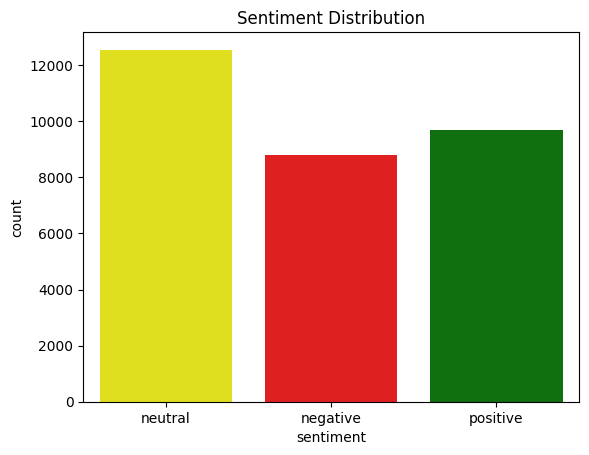

In [9]:
#sentiment values count
sns.countplot(data=train, x='sentiment', hue='sentiment', palette={'negative': 'red', 'positive': 'green','neutral':'yellow'}),
plt.title("Sentiment Distribution");

In [10]:
#average age according to type of sentiment
train['Age of User'].unique()

<ArrowStringArray>
['0-20', '21-30', '31-45', '46-60', '60-70', '70-100']
Length: 6, dtype: str

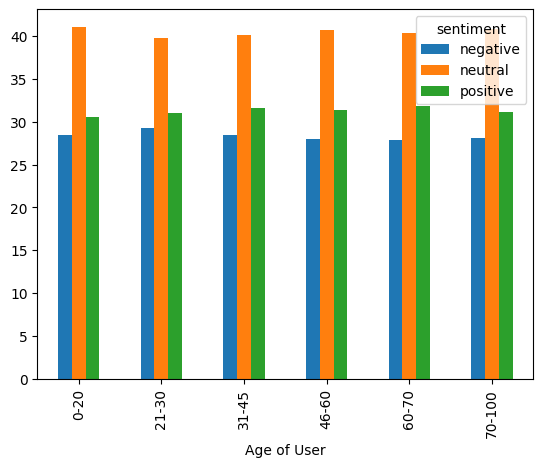

In [11]:
# average sentiment by age
((train.groupby(['Age of User','sentiment'])['sentiment'].value_counts())/train.groupby(['Age of User'])['Age of User'].value_counts() * 100).unstack().plot(kind = 'bar', stacked  = False);

# Feature Engineering

In [12]:
#for cleaning text feature
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"@\w+", "", text)     # remove mentions
    text = re.sub(r"#\w+", "", text)     # remove hashtags
    return text.strip()


In [13]:
train['cleaned_text'] = train.text.apply(clean_text)
train.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),cleaned_text
0,cb774db0d1,"I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60,"i`d have responded, if i were going"
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,negative,noon,21-30,Albania,2877797,27400.0,105,sooo sad i will miss you here in san diego!!!
2,088c60f138,my boss is bullying me...,negative,night,31-45,Algeria,43851044,2381740.0,18,my boss is bullying me...
3,9642c003ef,what interview! leave me alone,negative,morning,46-60,Andorra,77265,470.0,164,what interview! leave me alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",negative,noon,60-70,Angola,32866272,1246700.0,26,"sons of ****, why couldn`t they put them on th..."


In [14]:
# sentiment to numeric
train['sentiment'] = np.where(train['sentiment'] == 'positive', 2, np.where(train['sentiment'] == 'negative', 0, 1))
train.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),cleaned_text
0,cb774db0d1,"I`d have responded, if I were going",1,morning,0-20,Afghanistan,38928346,652860.0,60,"i`d have responded, if i were going"
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,0,noon,21-30,Albania,2877797,27400.0,105,sooo sad i will miss you here in san diego!!!
2,088c60f138,my boss is bullying me...,0,night,31-45,Algeria,43851044,2381740.0,18,my boss is bullying me...
3,9642c003ef,what interview! leave me alone,0,morning,46-60,Andorra,77265,470.0,164,what interview! leave me alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",0,noon,60-70,Angola,32866272,1246700.0,26,"sons of ****, why couldn`t they put them on th..."


In [15]:
# X and Y
x = train.cleaned_text
y = train.sentiment

In [16]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(24811,)
(6203,)
(24811,)
(6203,)


In [17]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch

In [18]:
#tokenization function
tokenizer = BertTokenizer.from_pretrained("google/bert_uncased_L-4_H-256_A-4")
def tokenize(text):
    return tokenizer.encode(text['text'], padding = 'max_length', truncation = True)


In [19]:
X_train = tokenizer(x_train.to_list(), padding = 'max_length', truncation = True,max_length=128)
X_test = tokenizer(x_test.to_list(), padding = 'max_length', truncation = True,max_length=128)

In [20]:
model  = BertForSequenceClassification.from_pretrained("google/bert_uncased_L-4_H-256_A-4", num_labels = 3)

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

In [21]:
# Define training arguments
training_args = TrainingArguments(
    output_dir=' results',
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,)



In [22]:
# 1. Define a custom PyTorch Dataset class
class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Reset index to ensure sequential indexing (0 to len-1)
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        # Convert list tokens to PyTorch tensors for each input feature
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Add the target sentiment label
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# 2. Instantiate the proper training and evaluation datasets
train_dataset = TweetDataset(X_train, y_train)
eval_dataset = TweetDataset(X_test, y_test)

# 3. Pass the corrected datasets to the Trainer
trainer = Trainer( 
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset 
)

In [23]:
#training model
trainer.train()

C:\Users\ajayn\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.661084,0.615859
2,0.582520,0.601533


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\ajayn\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=6204, training_loss=0.6740813043177474, metrics={'train_runtime': 1206.4975, 'train_samples_per_second': 41.129, 'train_steps_per_second': 5.142, 'total_flos': 122946261911040.0, 'train_loss': 0.6740813043177474, 'epoch': 2.0})

In [71]:
#let's make a function for prediction
def predict_sentiment(text, model = trainer.model, tokenizer = tokenizer, clean_fn = clean_text):
    # 1. Put model in evaluation mode
    model.eval()
    
    # 2. Apply your preprocessing/cleaning function
    cleaned_text = clean_fn(text)
    
    # 3. Tokenize the input exactly like the training data
    inputs = tokenizer(
        cleaned_text, 
        padding='max_length', 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"  # Returns PyTorch tensors directly
    )
    
    # 4. Move inputs to the same device as the model (GPU or CPU)
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 5. Disable gradient calculation for pure inference efficiency
    with torch.no_grad():
        outputs = model(**inputs)
        
    # 6. Extract raw logit scores and apply argmax to get the highest probability index
    logits = outputs.logits
    predicted_class_idx = torch.argmax(logits, dim=1).item()
    
    # 7. Map the numerical class back to your original labels
    # (Since 0 = negative, 1 = neutral, 2 = positive based on your mapping)
    # label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    return predicted_class_idx

In [72]:
# let's predict test data
test_preds = x_test.apply(predict_sentiment)

In [81]:
#classification metrics
cfr = confusion_matrix(y_test, test_preds)

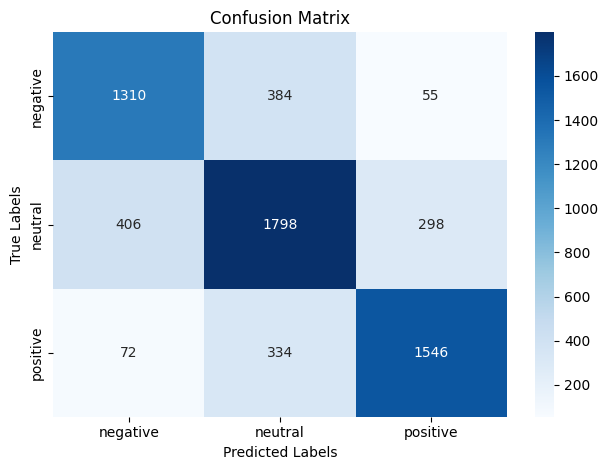

In [82]:
sns.heatmap(
    cfr, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels= [ 'negative', 'neutral', 'positive'], 
    yticklabels= [ 'negative', 'neutral', 'positive']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

In [83]:
import os

# Define your local directory pathway
output_dir = "./bert_finetuned_local"

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Option A: If you used Hugging Face Trainer
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bert_finetuned_local\\tokenizer_config.json',
 './bert_finetuned_local\\tokenizer.json')